In [219]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import warnings

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

<b><i>Load Datasets and Describe them</i></b>

In [174]:
df1 = pd.read_csv("IN-WE_carbon_intensity.csv")
df2 = pd.read_csv("IN-WE_renewable_percentage.csv")

In [175]:
df1.head()

,zone,carbonIntensity,datetime,updatedAt,createdAt,emissionFactorType,flowTraced,isEstimated,estimationMethod
0,IN-WE,531,2026-08-30T03:00:00.000Z,2026-08-31T05:20:09.085Z,2026-08-29T18:20:13.429Z,lifecycle,True,False,NaN
1,IN-WE,486,2026-08-30T04:00:00.000Z,2026-08-31T05:20:10.705Z,2026-08-29T18:20:22.493Z,lifecycle,True,False,NaN
2,IN-WE,469,2026-08-30T05:00:00.000Z,2026-08-31T05:20:06.131Z,2026-08-29T21:19:55.119Z,lifecycle,True,False,NaN
3,IN-WE,459,2026-08-30T06:00:00.000Z,2026-08-31T05:20:14.731Z,2026-08-29T22:19:47.438Z,lifecycle,True,False,NaN
4,IN-WE,465,2026-08-30T07:00:00.000Z,2026-08-31T05:20:04.432Z,2026-08-29T23:20:30.296Z,lifecycle,True,False,NaN


In [176]:
df2.head()

,zone,datetime,updatedAt,createdAt,unit,value,flowTraced,isEstimated,estimationMethod
0,IN-WE,2026-08-30T03:00:00.000Z,2026-08-31T05:20:09.085Z,2026-08-29T18:20:13.429Z,%,33,True,False,NaN
1,IN-WE,2026-08-30T04:00:00.000Z,2026-08-31T05:20:10.705Z,2026-08-29T18:20:22.493Z,%,39,True,False,NaN
2,IN-WE,2026-08-30T05:00:00.000Z,2026-08-31T05:20:06.131Z,2026-08-29T21:19:55.119Z,%,41,True,False,NaN
3,IN-WE,2026-08-30T06:00:00.000Z,2026-08-31T05:20:14.731Z,2026-08-29T22:19:47.438Z,%,43,True,False,NaN
4,IN-WE,2026-08-30T07:00:00.000Z,2026-08-31T05:20:04.432Z,2026-08-29T23:20:30.296Z,%,42,True,False,NaN


In [177]:
print("SHAPE:")
print("Carbon Emission csv: ", df1.shape)
print("Renewable Percentage csv: ", df2.shape)

SHAPE:
Carbon Emission csv:  (221, 9)
Renewable Percentage csv:  (221, 9)


In [178]:
# Conversion to datetime data type
df1["datetime"] = pd.to_datetime(df1["datetime"])
df2["datetime"] = pd.to_datetime(df2["datetime"])

In [179]:
print("Carbon Emission csv:")
print("Rows: ", len(df1))
print("Columns: ", len(df1.columns))
print("Date range: ", end="")
print(df1["datetime"].min(), end=", ")
print(df1["datetime"].max())
print("Data types: ", end="")
print(df1["datetime"].dtypes, end="\n\n")

print("Renewable Percentage csv:")
print("Rows: ", len(df2))
print("Columns: ", len(df2.columns))
print("Date range: ", end="")
print(df2["datetime"].min(), end=", ")
print(df2["datetime"].max())
print("Data types: ", end="")
print(df2["datetime"].dtypes)

Carbon Emission csv:
Rows:  221
Columns:  9
Date range: 2026-08-30 03:00:00+00:00, 2026-09-08 07:00:00+00:00
Data types: datetime64[ns, UTC]

Renewable Percentage csv:
Rows:  221
Columns:  9
Date range: 2026-08-30 03:00:00+00:00, 2026-09-08 07:00:00+00:00
Data types: datetime64[ns, UTC]


In [180]:
# Check missing values
print("Carbon Emission csv:")
print(df1.isnull().sum(), end="\n\n")
print("Renewable Percentage csv:")
print(df2.isnull().sum())

Carbon Emission csv:
zone                    0
carbonIntensity         0
datetime                0
updatedAt               0
createdAt               0
emissionFactorType      0
flowTraced              0
isEstimated             0
estimationMethod      208
dtype: int64

Renewable Percentage csv:
zone                  0
datetime              0
updatedAt             0
createdAt             0
unit                  0
value                 0
flowTraced            0
isEstimated           0
estimationMethod    208
dtype: int64


In [181]:
# Check duplicate time stamps
print("Duplicate timestamps carbon emission csv: ", df1["datetime"].duplicated().sum())
print("Duplicate timestamps renewable percentage csv: ", df2["datetime"].duplicated().sum())

Duplicate timestamps carbon emission csv:  0
Duplicate timestamps renewable percentage csv:  0


In [182]:
# Check if value is actually hourly
print("carbon emission csv: ", df1["datetime"].diff().value_counts().head(10), end="\n\n")
print("carbon emission csv: ", df2["datetime"].diff().value_counts().head(10))

# Sort data based on date
df1 = df1.sort_values("datetime")
df2 = df2.sort_values("datetime")

carbon emission csv:  datetime
0 days 01:00:00    220
Name: count, dtype: int64

carbon emission csv:  datetime
0 days 01:00:00    220
Name: count, dtype: int64


In [183]:
# Remove columns not needed for time series plot
df1 = df1[["datetime", "carbonIntensity"]]
df2 = df2[["datetime", "value"]]

df2.rename(columns={"value": "RenewablePercentage"}, inplace=True)

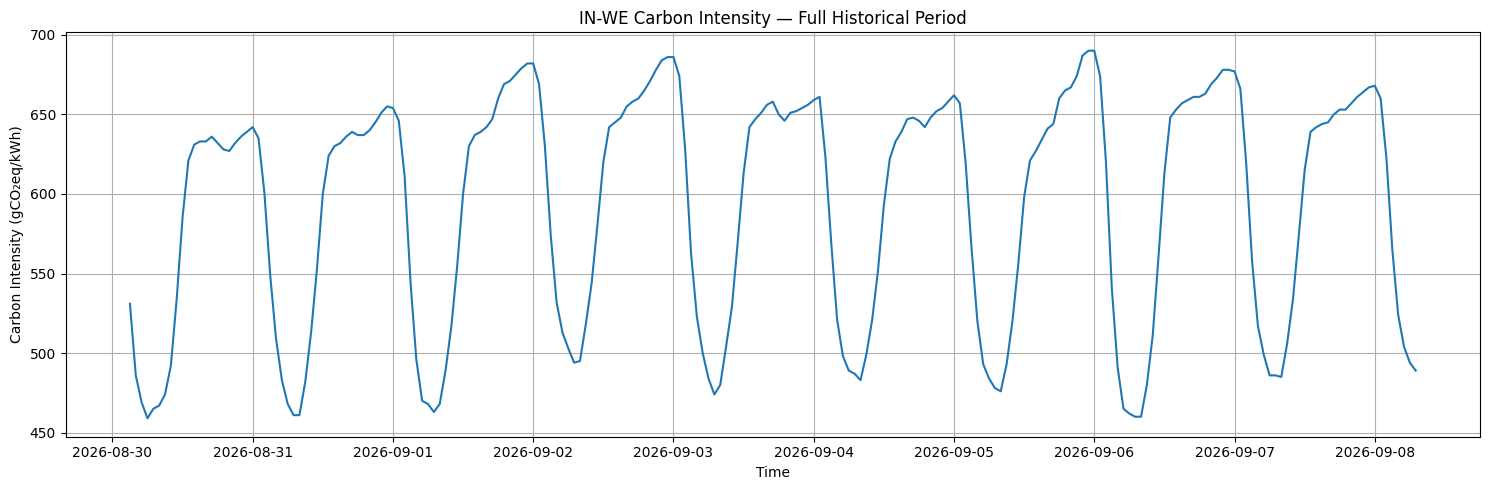

In [184]:
# Plot of carbon emission
plt.figure(figsize=(15, 5))

plt.plot(df1["datetime"], df1["carbonIntensity"])

plt.xlabel("Time")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.title("IN-WE Carbon Intensity — Full Historical Period")

plt.grid(True)
plt.tight_layout()
plt.show()

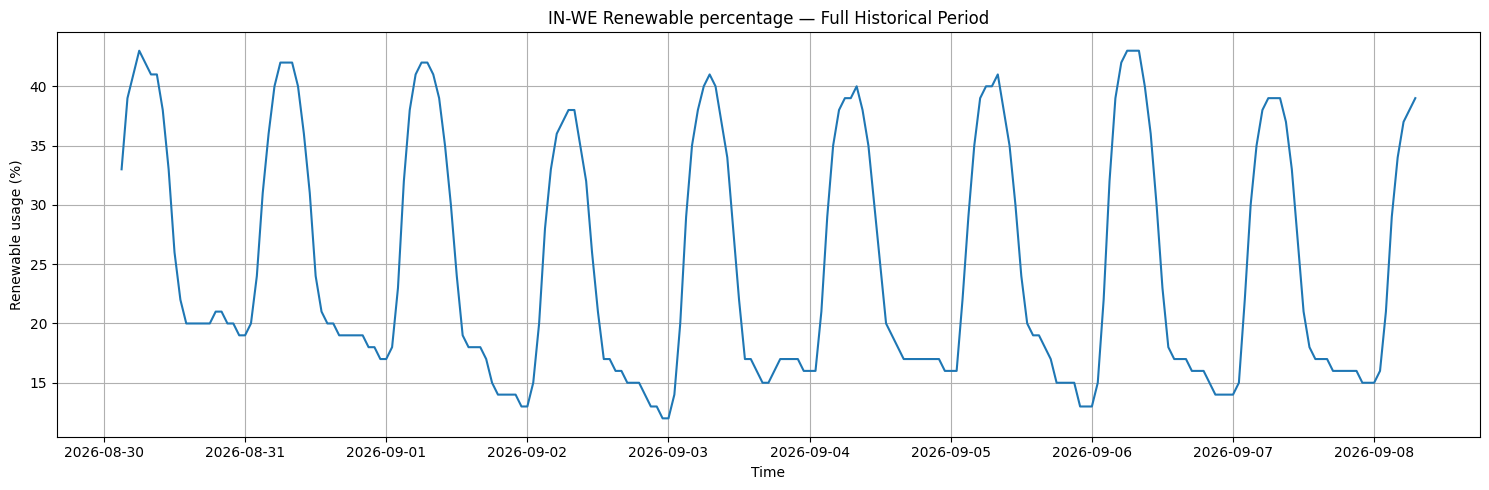

In [186]:
# Plot of renewable percentage
plt.figure(figsize=(15, 5))

plt.plot(df2["datetime"], df2["RenewablePercentage"])

plt.xlabel("Time")
plt.ylabel("Renewable usage (%)")
plt.title("IN-WE Renewable percentage — Full Historical Period")

plt.grid(True)
plt.tight_layout()
plt.show()

In [187]:
df1_1 = df1.copy()
df2_1 = df2.copy()
df1 = df1.set_index("datetime")["carbonIntensity"]
df2 = df2.set_index("datetime")["RenewablePercentage"]

<b><i>Trend and Seasonality Analysis</i></b>

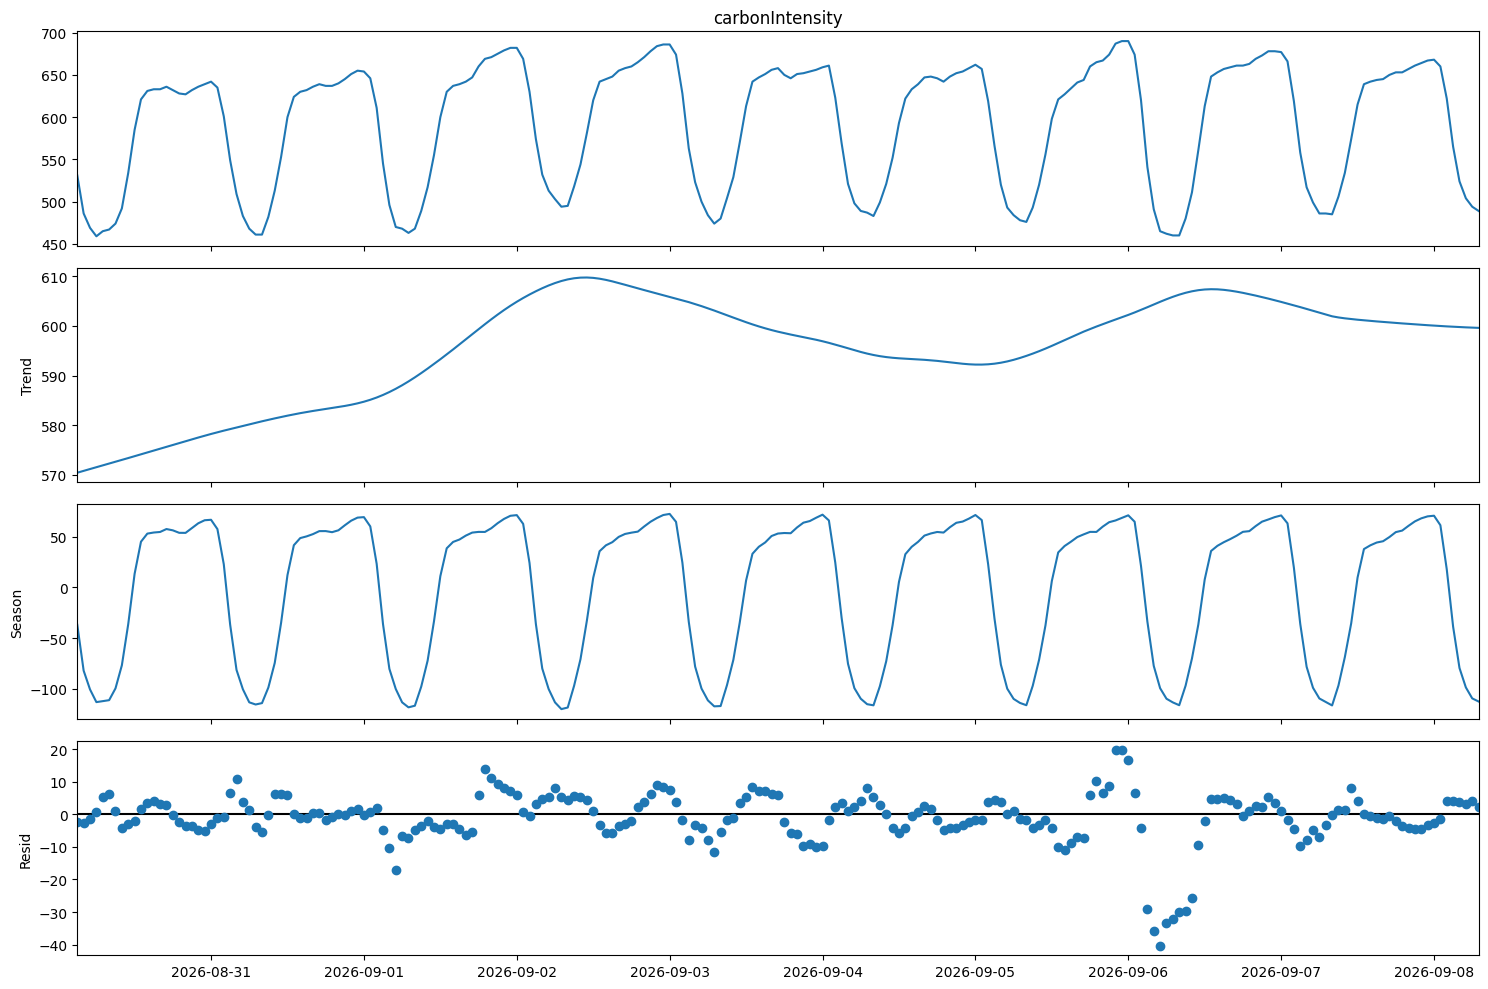

In [188]:
# Trend and Seasonality in carbon emission csv
stl_daily = STL(
    df1,
    period=24,
    robust=True
).fit()

fig = stl_daily.plot()

fig.set_size_inches(15, 10)

plt.tight_layout()
plt.show()

<b>Trend: </b>dataset does not exhibit a monotonic increase or decrease as trend

<b>Seasonality: </b>dataset exhibits a strong daily seasonality

<b>Residual: </b>After removing the trend and daily seasonal component, the residuals are comparatively small for most observations, although several larger deviations occur around September 6

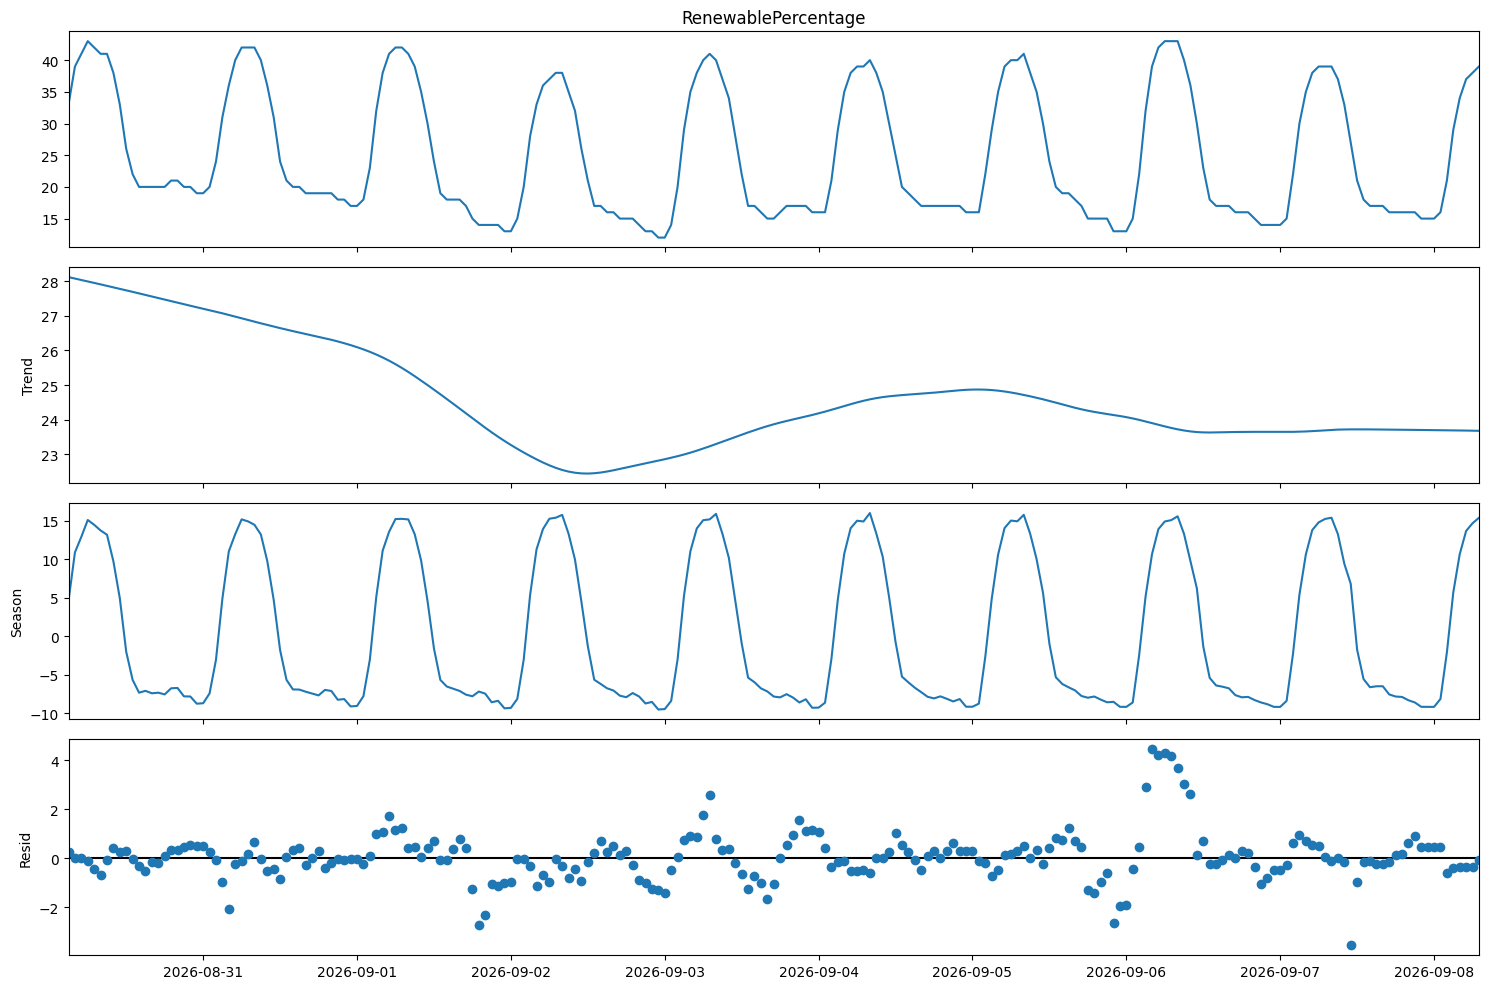

In [189]:
# Trend and Seasonality in renewable percentage csv
st2_daily = STL(
    df2,
    period=24,
    robust=True
).fit()

fig = st2_daily.plot()

fig.set_size_inches(15, 10)

plt.tight_layout()
plt.show()

<b>Trend: </b>dataset exhibits a decreasing trend but not a monotonic decrease as trend

<b>Seasonality: </b>dataset exhibits a strong daily seasonality

<b>Residual: </b>Most residuals are fairly close to zero, with a few larger deviations

<b><i>Rolling Mean and Rolling Standard Deviation</i></b>

In [190]:
rolling_mean_df1 = df1.rolling(window=24).mean()
rolling_std_df1 = df1.rolling(window=24).std()

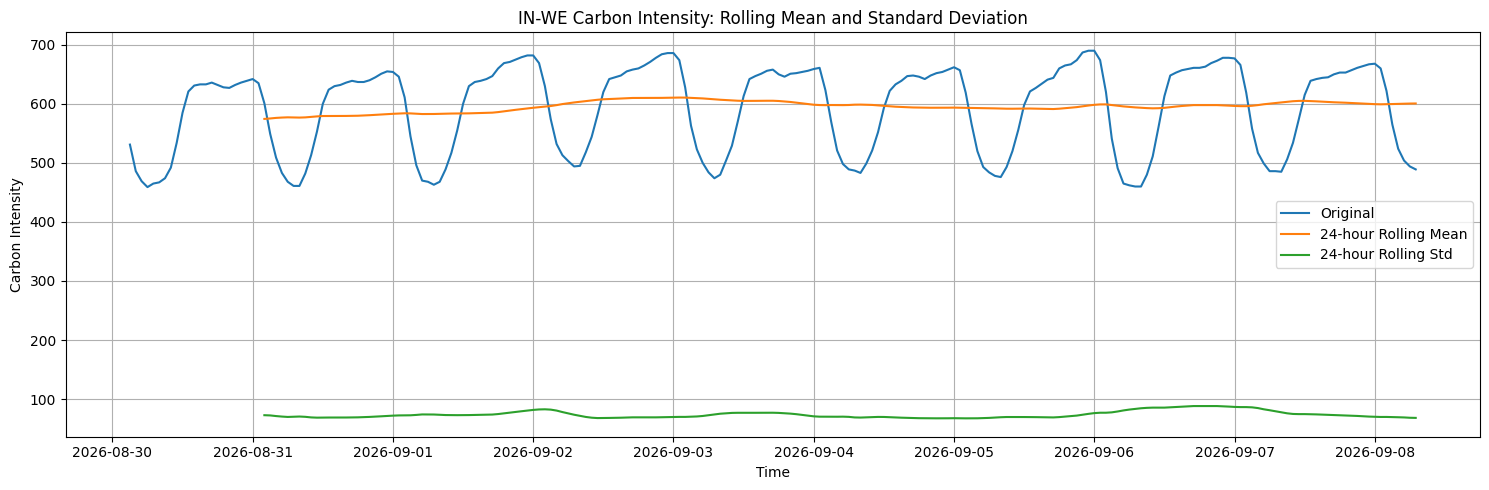

In [191]:
plt.figure(figsize=(15, 5))

plt.plot(df1, label="Original")
plt.plot(rolling_mean_df1, label="24-hour Rolling Mean")
plt.plot(rolling_std_df1, label="24-hour Rolling Std")

plt.xlabel("Time")
plt.ylabel("Carbon Intensity")
plt.title("IN-WE Carbon Intensity: Rolling Mean and Standard Deviation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [192]:
rolling_mean_df2 = df2.rolling(window=24).mean()
rolling_std_df2 = df2.rolling(window=24).std()

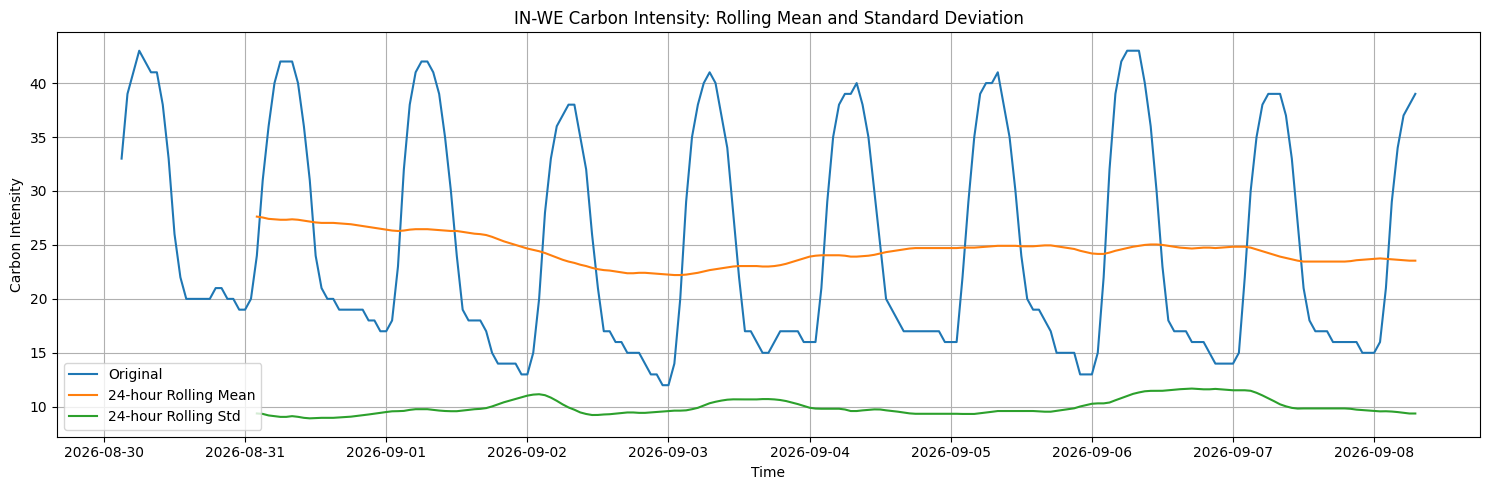

In [193]:
plt.figure(figsize=(15, 5))

plt.plot(df2, label="Original")
plt.plot(rolling_mean_df2, label="24-hour Rolling Mean")
plt.plot(rolling_std_df2, label="24-hour Rolling Std")

plt.xlabel("Time")
plt.ylabel("Carbon Intensity")
plt.title("IN-WE Carbon Intensity: Rolling Mean and Standard Deviation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<b><i>ADF Test</i></b>

In [194]:
adf_result_df1 = adfuller(df1)

print("ADF results for carbon emission dataset:")

print("ADF Statistic:", adf_result_df1[0])
print("p-value:", adf_result_df1[1])

for key, value in adf_result_df1[4].items():
    print(f"Critical Value ({key}): {value}")

print()
if adf_result_df1[1] < 0.05:
    print("The time series plot is stationary")
else:
    print("The time series plot is non-stationary")

ADF results for carbon emission dataset:
ADF Statistic: -4.593305252360719
p-value: 0.0001328898951875093
Critical Value (1%): -3.4626576734812318
Critical Value (5%): -2.8757444215841326
Critical Value (10%): -2.5743412314098753

The time series plot is stationary


In [195]:
adf_result_df2 = adfuller(df2)

print("ADF results for renewable percentage dataset:")

print("ADF Statistic:", adf_result_df2[0])
print("p-value:", adf_result_df2[1])

for key, value in adf_result_df2[4].items():
    print(f"Critical Value ({key}): {value}")

print()
if adf_result_df2[1] < 0.05:
    print("The time series plot is stationary")
else:
    print("The time series plot is non-stationary")

ADF results for renewable percentage dataset:
ADF Statistic: -4.265579304708102
p-value: 0.0005092931614084961
Critical Value (1%): -3.4626576734812318
Critical Value (5%): -2.8757444215841326
Critical Value (10%): -2.5743412314098753

The time series plot is stationary


<i><b>KPSS Test </b>(To verify again)</i>

In [196]:
kpss_result_df1 = kpss(
    df1,
    regression="c",
    nlags="auto"
)

print("KPSS results for carbon emission dataset:")
print("KPSS Statistic:", kpss_result_df1[0])
print("p-value:", kpss_result_df1[1])

for key, value in kpss_result_df1[3].items():
    print(f"Critical Value ({key}): {value}")

print()
if kpss_result_df1[1] >= 0.05:
    print("The time series plot is stationary")
else:
    print("The time series plot is non-stationary")

KPSS results for carbon emission dataset:
KPSS Statistic: 0.08381408913783576
p-value: 0.1
Critical Value (10%): 0.347
Critical Value (5%): 0.463
Critical Value (2.5%): 0.574
Critical Value (1%): 0.739

The time series plot is stationary


In [197]:
kpss_result_df2 = kpss(
    df2,
    regression="c",
    nlags="auto"
)

print("KPSS results for renewable percentage dataset:")
print("KPSS Statistic:", kpss_result_df2[0])
print("p-value:", kpss_result_df2[1])

for key, value in kpss_result_df2[3].items():
    print(f"Critical Value ({key}): {value}")

print()
if kpss_result_df2[1] >= 0.05:
    print("The time series plot is stationary")
else:
    print("The time series plot is non-stationary")

KPSS results for renewable percentage dataset:
KPSS Statistic: 0.08825751367389843
p-value: 0.1
Critical Value (10%): 0.347
Critical Value (5%): 0.463
Critical Value (2.5%): 0.574
Critical Value (1%): 0.739

The time series plot is stationary


<b><i>ACF and PACF Plots</i></b>

<Figure size 1500x500 with 0 Axes>

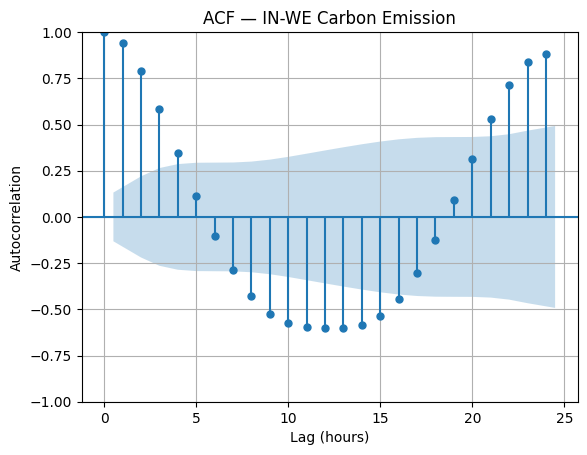

<Figure size 1500x500 with 0 Axes>

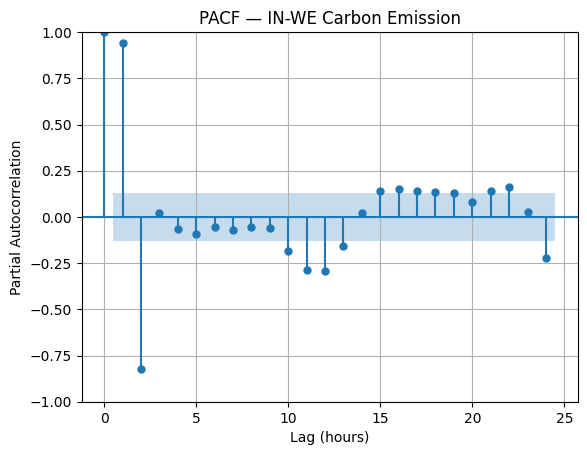

In [198]:
# ACF Plot of carbon emission dataset
plt.figure(figsize=(15, 5))

plot_acf(
    df1,
    lags=24
)

plt.title("ACF — IN-WE Carbon Emission")
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()


# PACF Plot of carbon emission dataset
plt.figure(figsize=(15, 5))

plot_pacf(
    df1, 
    lags=24, 
    method="ywm"
)

plt.title("PACF — IN-WE Carbon Emission")
plt.xlabel("Lag (hours)")
plt.ylabel("Partial Autocorrelation")
plt.grid(True)
plt.show()

<b>Observations for ACF plot of carbon emission dataset:</i></b>  
&emsp;1) <b>Lag 1 ~ 0.95</b> shows very strong dependence on previous hour   
&emsp;2) Correlation gradually reducues and becomes negative in lag 6  
&emsp;3) Strong negative correlation in lags 12 to 14  
&emsp;4) <b>Lag 24 ~ 0.9</b> shows strong dependence on value the same time yesterday  
  
<b>Observations for ACF plot of carbon emission dataset:</i></b>  
&emsp;1) Very strong partial autocorrelation at lags 1 and 2  
&emsp;2) Very strong negative partial autocorrelation at lag 3  
&emsp;3) Partial autocorrelation at every other lag is insignificant  

<Figure size 1500x500 with 0 Axes>

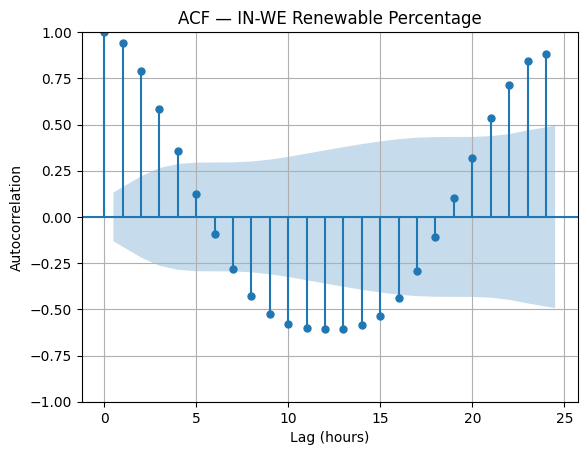

<Figure size 1500x500 with 0 Axes>

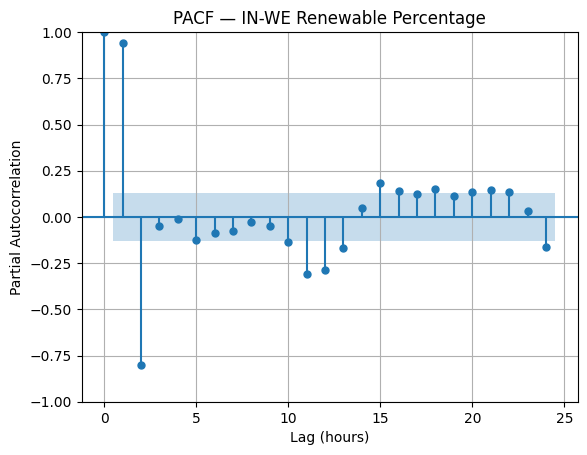

In [199]:
# ACF Plot of renewable percentage dataset
plt.figure(figsize=(15, 5))

plot_acf(
    df2,
    lags=24
)

plt.title("ACF — IN-WE Renewable Percentage")
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()


# PACF Plot of renewable percentage dataset
plt.figure(figsize=(15, 5))

plot_pacf(
    df2, 
    lags=24, 
    method="ywm"
)

plt.title("PACF — IN-WE Renewable Percentage")
plt.xlabel("Lag (hours)")
plt.ylabel("Partial Autocorrelation")
plt.grid(True)
plt.show()

<b>Observations for ACF plot of carbon emission dataset:</i></b>  
&emsp;1) <b>Lag 1 ~ 0.95</b> shows very strong dependence on previous hour   
&emsp;2) Correlation gradually reducues and becomes negative in lag 6  
&emsp;3) Strong negative correlation in lags 12 to 14  
&emsp;4) <b>Lag 24 ~ 0.9</b> shows strong dependence on value the same time yesterday  
  
<b>Observations for ACF plot of carbon emission dataset:</i></b>  
&emsp;1) Very strong partial autocorrelation at lags 1 and 2  
&emsp;2) Very strong negative partial autocorrelation at lag 3  
&emsp;3) Partial autocorrelation at every other lag is insignificant  

 <b><i>Correlation between carbon emission and renewable usage percentage</i></b>

In [201]:
df = pd.merge(
    df1_1,
    df2_1,
    on="datetime",
    how="inner"
)

df = df.set_index("datetime")

df.head()

,carbonIntensity,RenewablePercentage
datetime,,
2026-08-30 03:00:00+00:00,531,33
2026-08-30 04:00:00+00:00,486,39
2026-08-30 05:00:00+00:00,469,41
2026-08-30 06:00:00+00:00,459,43
2026-08-30 07:00:00+00:00,465,42


In [207]:
correlation = df["carbonIntensity"].corr(df["RenewablePercentage"])
print("Correlation coefficient between carbon emission and renewable usage percentage: ", correlation)

magnitude = ""
direction = ""

if abs(correlation) <= 1 and abs(correlation) > 0.7:
    magnitude = "very strong "
elif abs(correlation) <= 0.7 and abs(correlation) > 0.3:
    magnitude = "moderately strong "
elif abs(correlation) <= 0.3 and abs(correlation) > 0:
    magnitude = "weak "

if correlation < 0:
    direction = "negative "
elif correlation > 0:
    direction = "positive "
else:
    direction = "neutral / no "

print(f"carbon emission and renewable usage percentage have a {magnitude}{direction}correlation")

Correlation coefficient between carbon emission and renewable usage percentage:  -0.9984137592154019
carbon emission and renewable usage percentage have a very strong negative correlation


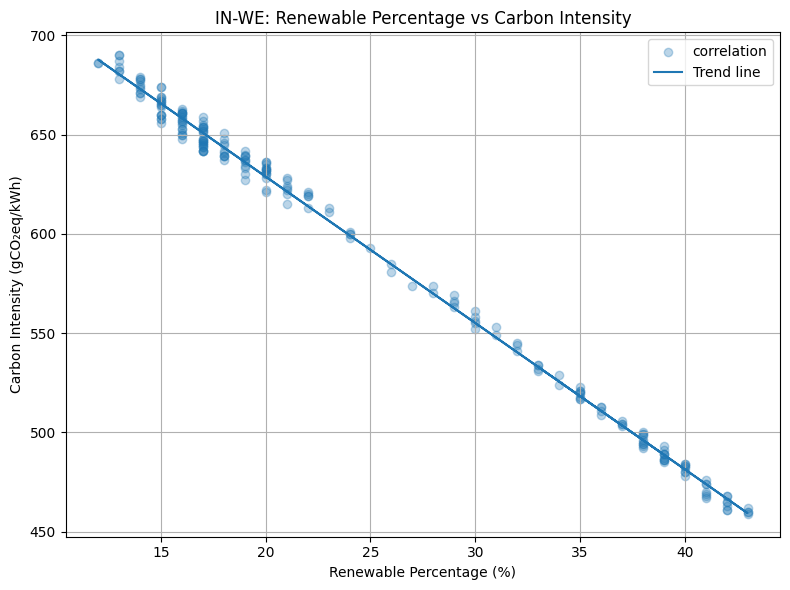

In [226]:
x = df["RenewablePercentage"]
y = df["carbonIntensity"]

mask = x.notna() & y.notna()
slope, intercept = np.polyfit(
    x[mask],
    y[mask],
    1
)

# Plotting the relationship between carbon emission and renewable usage percentage
plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    alpha=0.3, 
    label="correlation"
)

plt.plot(
    x,
    slope * x + intercept, 
    label="Trend line"
)

plt.xlabel("Renewable Percentage (%)")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.title("IN-WE: Renewable Percentage vs Carbon Intensity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

From the plot, we can see that the the relationship is inverse.
If one increases, the other decreases, and vice versa.

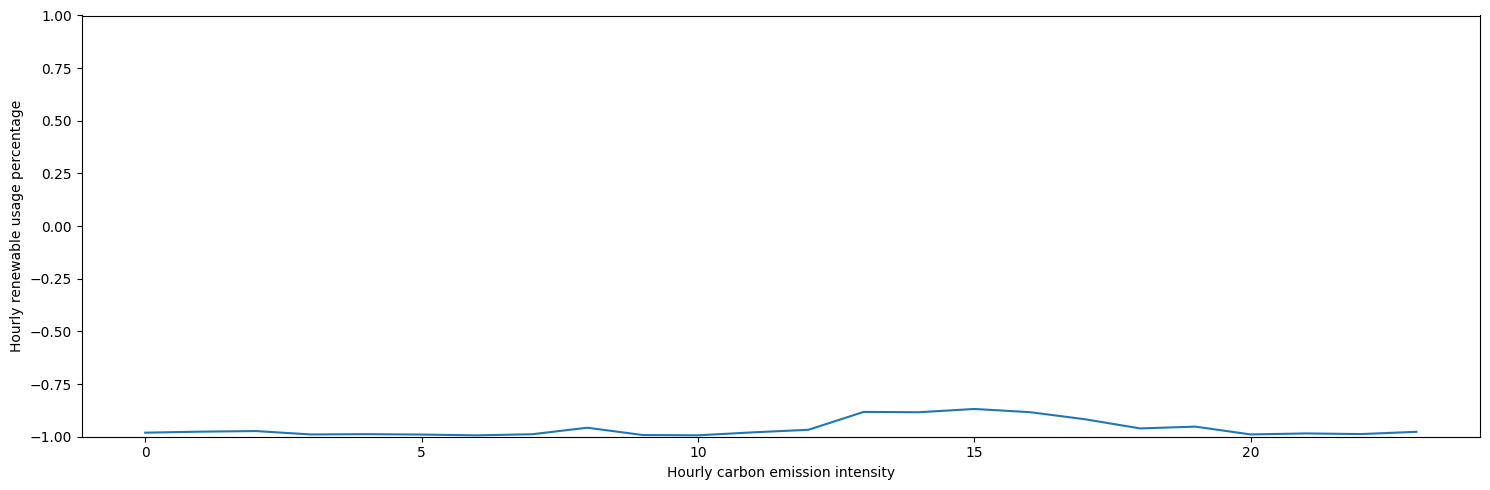

In [227]:
df_temp = df.copy()
df_temp["hour"] = df_temp.index.hour

hourly_corr = df_temp.groupby("hour").apply(
    lambda x: x["carbonIntensity"].corr(
        x["RenewablePercentage"]
    )
)


plt.figure(figsize=(15, 5))

plt.plot(hourly_corr)

plt.xlabel("Hourly carbon emission intensity")
plt.ylabel("Hourly renewable usage percentage")
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

From the above plot, we can see that carbon emission and renewable usage percentage are inversely related to eachother in every hour of the day

<i><b>Key Findings</b></i>

<b>KEY FINDINGS: <i>Carbon emission intensity</i></b>  
&emsp;1) The data has a daily seasonality (confiremed by very stron autocorrelation at lag=24)  
&emsp;2) The data does not have a monotonic trend

<b>KEY FINDINGS: <i>Renewable energy usage percentage</i></b>  
&emsp;1) The data has a daily seasonality (confiremed by very stron autocorrelation at lag=24)  
&emsp;2) The data does not have a monotonic trend

<b>KEY FINDINGS: <i>Correlation between carbon emission and renewable usage</i></b>  
&emsp;These parameters are inversely related to eachother. if one increases, other decreases, and vice versa